# XGBoost Regressor Notebook (Using CRSP Data)

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
import optuna
from sklearn.metrics import mean_absolute_error

In [37]:
NUM_COL = 'prc'
DATE_COL = 'date'
TICKER_COL = 'permno'
SPLIT_DATE = "2014-01-01"
START_BALANCE = 1000
EXIT_PROP = 1.0

##### Data Prep

In [3]:
data = pd.read_csv('./data/crsp_dsf.csv')
data[DATE_COL] = data[DATE_COL].astype('datetime64[s]')
data = data.dropna(subset=NUM_COL).reset_index(drop=True)
data.head()

,permno,date,bidlo,askhi,prc,vol,ret,retx,bid,ask,shrout,cfacpr,cfacshr,openprc,numtrd
0,10001,2010-01-04,10.10,10.5800,10.25,18500.0,-0.004854,-0.004854,10.21,10.26,4361.0,1.0,1.0,10.58,NaN
1,10001,2010-01-05,9.80,10.3600,10.19,23200.0,-0.005854,-0.005854,10.15,10.19,4361.0,1.0,1.0,10.18,NaN
2,10001,2010-01-06,10.15,10.4800,10.31,18700.0,0.011776,0.011776,10.31,10.35,4361.0,1.0,1.0,10.18,NaN
3,10001,2010-01-07,9.91,10.3695,9.96,29200.0,-0.033948,-0.033948,9.95,9.97,4361.0,1.0,1.0,10.28,NaN
4,10001,2010-01-08,10.00,10.4000,10.34,25100.0,0.038153,0.038153,10.34,10.37,4361.0,1.0,1.0,10.00,NaN


In [38]:
reg_df = data.sort_values([TICKER_COL, DATE_COL]).copy()

reg_df["target"] = (reg_df.groupby(TICKER_COL)[NUM_COL].shift(-1))

for lag in [1, 2, 3, 5, 10, 20]:
    reg_df[f"lag_prc_{lag}"] = (reg_df.groupby(TICKER_COL)[NUM_COL].shift(lag))

for lag in [1, 2, 3, 5, 10]:
    reg_df[f"lag_ret_{lag}"] = (reg_df.groupby(TICKER_COL)["ret"].shift(lag))

for win in [5, 10, 20, 50]:
    reg_df[f"ma_{win}"] = (reg_df.groupby(TICKER_COL)[NUM_COL].transform(lambda x: x.rolling(win).mean()))

reg_df["vol_20"] = (reg_df.groupby(TICKER_COL)["ret"].transform(lambda x: x.rolling(20).std()))

reg_df["vol_ma_20"] = (reg_df.groupby(TICKER_COL)["vol"].transform(lambda x: x.rolling(20).mean()))

reg_df["vol_ratio"] = reg_df["vol"] / reg_df["vol_ma_20"]

reg_df["spread"] = reg_df["ask"] - reg_df["bid"]

FEATURES = ["lag_prc_1", "lag_prc_2", "lag_prc_3", "lag_prc_5", "lag_prc_10", "lag_prc_20",
            "lag_ret_1", "lag_ret_2", "lag_ret_3", "lag_ret_5", "lag_ret_10",
            "ma_5", "ma_10", "ma_20", "ma_50", "vol_20", "vol_ratio", "spread", "vol"]

reg_df = reg_df[[TICKER_COL, DATE_COL, NUM_COL, "target"] + FEATURES].dropna().reset_index(drop=True)

train_df = reg_df[reg_df[DATE_COL] < SPLIT_DATE]
test_df = reg_df[reg_df[DATE_COL] >= SPLIT_DATE]

X_train = train_df[FEATURES]
y_train = train_df["target"]

X_test = test_df[FEATURES]
y_test = test_df["target"]

reg_df.head()

,permno,date,prc,target,lag_prc_1,lag_prc_2,lag_prc_3,lag_prc_5,lag_prc_10,lag_prc_20,...,lag_ret_5,lag_ret_10,ma_5,ma_10,ma_20,ma_50,vol_20,vol_ratio,spread,vol
0,10001,2010-03-16,9.9700,9.9889,9.9100,9.9100,10.0001,10.0200,10.0501,10.0924,...,0.002000,0.005010,9.96266,9.98628,10.000070,10.082512,0.006309,0.736127,0.02,6500.0
1,10001,2010-03-17,9.9889,10.1300,9.9700,9.9100,9.9100,10.0232,10.0250,10.0000,...,0.000319,-0.002498,9.95580,9.98267,9.999515,10.077290,0.005973,0.930997,0.03,8500.0
2,10001,2010-03-18,10.1300,10.0400,9.9889,9.9700,9.9100,10.0001,10.0045,10.0700,...,0.002185,-0.002045,9.98178,9.99522,10.002515,10.076090,0.006583,2.542787,0.03,26000.0
3,10001,2010-03-19,10.0400,10.0000,10.1300,9.9889,9.9700,9.9100,10.0000,10.0101,...,-0.009010,-0.000450,10.00778,9.99922,10.004010,10.070690,0.006765,0.848193,0.03,8800.0
4,10001,2010-03-22,10.0000,10.0100,10.0400,10.1300,9.9889,9.9100,10.0000,9.9400,...,0.000000,0.000000,10.02578,9.99922,10.007010,10.071490,0.006624,0.613861,0.05,6200.0


##### Basline Model

In [10]:
model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=0,
    n_jobs=-1
)

model.fit(X_train, y_train)
preds = model.predict(X_test)

In [43]:
preds_df = test_df[[DATE_COL, TICKER_COL, NUM_COL, "target"]].copy()
preds_df['pred'] = preds

##### Trading Strategy

In [44]:
def trade_strat_single(df, curr_b=1000, exit_prop=1.0):
    ### Defaults to starting balance of 1000 and full exits
    curr_vol = 0

    returns = []

    for _, row in df.iterrows():

        pred = row['pred']
        num = row[NUM_COL]

        ### Buy signal
        if pred >= num:
            ### Only buy if we have balance
            ### Otherwise we will just be holding the stock
            if curr_b > 0:
                curr_vol += curr_b / num
                curr_b = 0

        ### Sell signal
        else:
            ### Only sell if we have volume to sell
            if curr_vol > 0:
                shares_sold = exit_prop * curr_vol
                curr_b += shares_sold * num
                curr_vol -= shares_sold
                
        ### Current Return of the Strategy
        ### Cash Balance + Value of Held Stock
        returns.append(curr_b + curr_vol * num)
    
    return returns

In [45]:
def trade_strat(data, tickers, curr_b=START_BALANCE, exit_prop=EXIT_PROP):
    ret_df = pd.DataFrame()
    for t in tickers:
        df = data[data[TICKER_COL] == t].reset_index(drop=True)
        returns = trade_strat_single(df, curr_b=curr_b, exit_prop=exit_prop)
        start_vol = START_BALANCE / df[NUM_COL].iloc[0]
        hold_ret = start_vol * df[NUM_COL].values
        stg_df = (
            df[[TICKER_COL, DATE_COL]]
            .copy()
            .assign(
                strat_ret=returns,
                hold_ret=hold_ret
            )
        )
        if len(ret_df) == 0:
            ret_df = stg_df.copy()
        else:
            ret_df = pd.concat([ret_df, stg_df])
    
    return ret_df

In [ ]:
# tickers = preds_df[TICKER_COL].unique()
# ret_df = trade_strat(preds_df, tickers)
# ret_df.to_csv(f"./data/xgboost_reg_baseline_model_returns.csv", index=False)

ret_df = pd.read_csv(f"./data/xgboost_reg_baseline_model_returns.csv")
ret_df[DATE_COL] = pd.to_datetime(ret_df[DATE_COL])

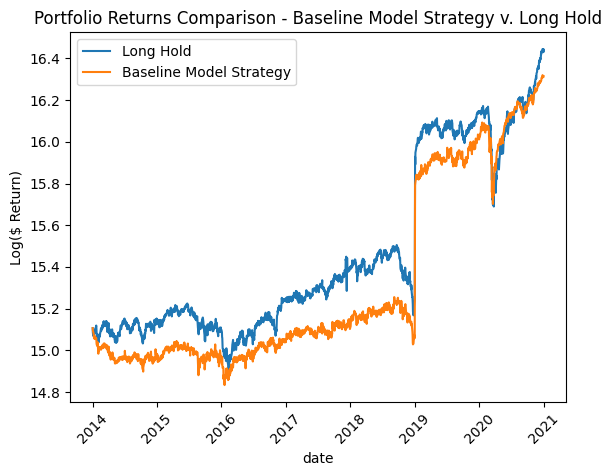

In [55]:
### There was some weird data corruption on the last day
plot_df = ret_df.groupby(by=DATE_COL).agg({"strat_ret" : "sum", "hold_ret" : "sum"}).iloc[:-1,:]

sns.lineplot(x=plot_df.index, y=np.log(plot_df['hold_ret']), label="Long Hold")
sns.lineplot(x=plot_df.index, y=np.log(plot_df['strat_ret']), label="Baseline Model Strategy")

plt.title("Portfolio Returns Comparison - Baseline Model Strategy v. Long Hold")
plt.ylabel("Log($ Return)")
plt.xticks(rotation=45)
plt.legend()
plt.show()

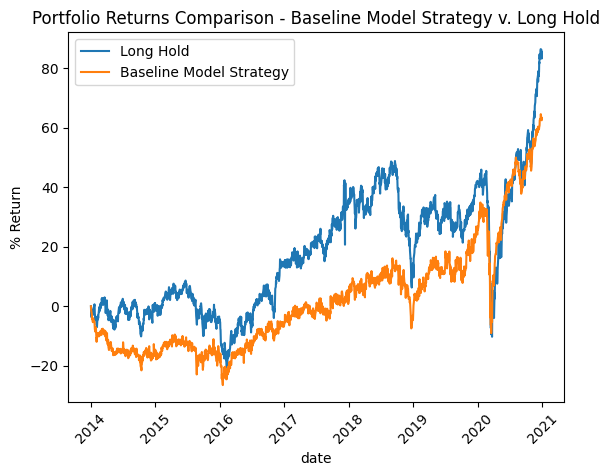

In [59]:
### There was some weird data corruption on the last day
plot_df = ret_df.groupby(by=DATE_COL).agg({"strat_ret" : "sum", "hold_ret" : "sum", TICKER_COL : "count"}).rename(columns={TICKER_COL:"num_stocks"}).iloc[:-1,:]
plot_df['base_bal'] = plot_df["num_stocks"] * START_BALANCE
plot_df["strat_pct_grwth"] = (plot_df["strat_ret"] / plot_df['base_bal'] - 1) * 100
plot_df["hold_pct_grwth"] = (plot_df["hold_ret"] / plot_df['base_bal'] - 1) * 100

sns.lineplot(x=plot_df.index, y=plot_df['hold_pct_grwth'], label="Long Hold")
sns.lineplot(x=plot_df.index, y=plot_df['strat_pct_grwth'], label="Baseline Model Strategy")

plt.title("Portfolio Returns Comparison - Baseline Model Strategy v. Long Hold")
plt.ylabel("% Return")
plt.xticks(rotation=45)
plt.legend()
plt.show()

##### Model Fine-Tuning

In [ ]:
# def objective(trial):

#     params = {
#         "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
#         "max_depth": trial.suggest_int("max_depth", 3, 10),
#         "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
#         "subsample": trial.suggest_float("subsample", 0.6, 1.0),
#         "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
#         "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
#     }

#     model = XGBRegressor(
#         **params,
#         random_state=0,
#         n_jobs=-1
#     )

#     model.fit(X_train, y_train)
#     preds = model.predict(X_test)

#     return mean_absolute_error(y_test, preds)

# study = optuna.create_study(direction="minimize")
# study.optimize(objective, n_trials=30)

# best_params = study.best_params